# Cohere Jupyter GUI

This notebook provides a GUI for Bragg CDI reconstruction, similar to the Qt `cohere_gui`.

## Usage
1. Use the **file browser** at the top to navigate to and select your experiment folder (the one containing `conf/`)
2. Click **"Load Selected Experiment"** to load the configuration
3. Use the tabs to view/modify settings
4. Run processing steps via the buttons in each tab

In [1]:
# Setup: ensure local modules are used (not shared venv installations)
import sys
import os

# Clear any cached cohere modules to avoid conflicts
for mod in list(sys.modules.keys()):
    if 'cohere' in mod:
        del sys.modules[mod]

# Add local paths at the START of sys.path (order matters!)
# These override any pip-installed versions in the shared venv
sys.path.insert(0, os.path.join(os.getcwd(), 'cohere_beamlines', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), 'cohere-ui', 'src'))
sys.path.insert(0, os.getcwd())

# Verify paths are correct
print("Using local modules:")
print(f"  Project: {os.getcwd()}")
print(f"  cohere-ui: {os.path.join(os.getcwd(), 'cohere-ui', 'src')}")
print(f"  cohere_beamlines: {os.path.join(os.getcwd(), 'cohere_beamlines', 'src')}")

# Install ipywidgets if not present
try:
    import ipywidgets
except ImportError:
    !pip install ipywidgets

Using local modules:
  Project: /Users/ksharaf/Codes/cohere_jup_interface
  cohere-ui: /Users/ksharaf/Codes/cohere_jup_interface/cohere-ui/src
  cohere_beamlines: /Users/ksharaf/Codes/cohere_jup_interface/cohere_beamlines/src


In [2]:
# Create and display the GUI
from jup_gui import CoherenceGUI

gui = CoherenceGUI()
gui.display()

# The GUI shows:
# 1. A file browser to select experiment directories
# 2. "Load Selected Experiment" button to load config
# 3. Tabs for Prep, Data, Reconstruction, Display settings

In [3]:
# Programmatic loading (alternative to using the file browser)
# Uncomment to load directly:

import os
exp_path = os.path.join(os.getcwd(), 'cohere_examples', 'example_workspace', 'scan_54')
if os.path.exists(exp_path):
    gui.load_experiment(exp_path)
    print(f"Loaded: {exp_path}")
    print(f"Tabs: {list(gui._tabs.keys())}")
else:
    print(f"Example not found: {exp_path}")
    print("Run: git submodule update --init")

Loaded: /Users/ksharaf/Codes/cohere_jup_interface/cohere_examples/example_workspace/scan_54
Tabs: ['instr', 'prep', 'data', 'rec', 'disp']


## Access Results

After running reconstruction, access results via `gui.results`

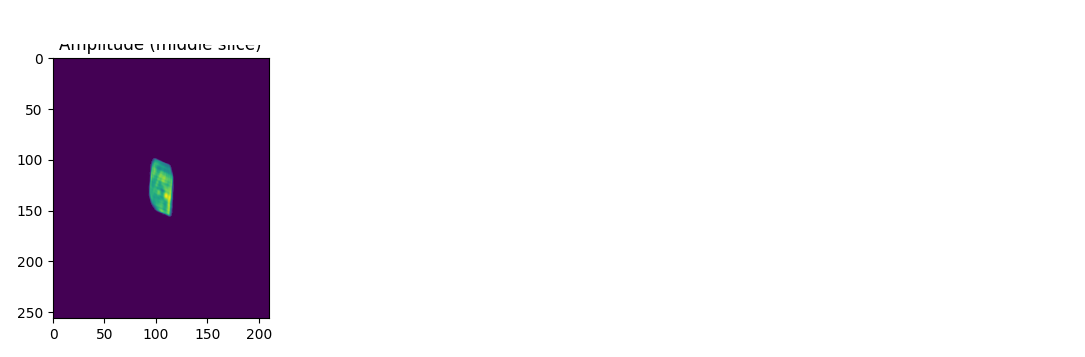

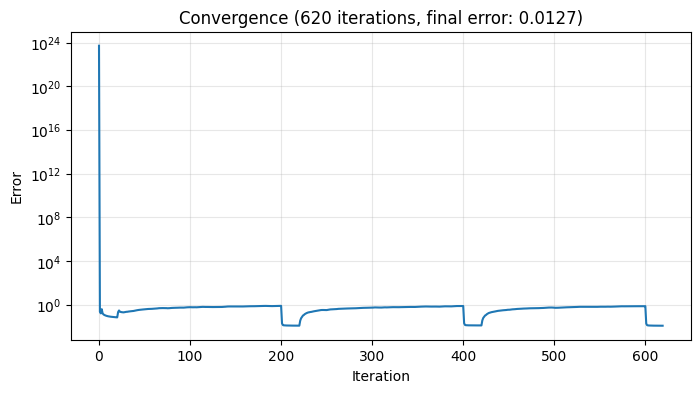

Image shape: (256, 256, 210), dtype: complex128
Support shape: (256, 256, 210)
Iterations: 620


In [4]:
# Visualize reconstruction results
import matplotlib.pyplot as plt
import numpy as np

# Reload results from disk
gui.results.reload()

image = gui.results.image
support = gui.results.support
errors = gui.results.errors

if image is not None:
    mid = image.shape[0] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    im0 = axes[0].imshow(np.abs(image[mid]))
    axes[0].set_title('Amplitude (middle slice)')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(np.angle(image[mid]), cmap='twilight')
    axes[1].set_title('Phase (middle slice)')
    plt.colorbar(im1, ax=axes[1])
    
    if support is not None:
        im2 = axes[2].imshow(support[mid])
        axes[2].set_title('Support (middle slice)')
        plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # Plot convergence curve
    if errors is not None:
        plt.figure(figsize=(8, 4))
        plt.semilogy(errors)
        plt.xlabel('Iteration')
        plt.ylabel('Error')
        plt.title(f'Convergence ({len(errors)} iterations, final error: {errors[-1]:.4f})')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    print(f"Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Support shape: {support.shape if support is not None else 'N/A'}")
    print(f"Iterations: {len(errors) if errors is not None else 'N/A'}")
else:
    print("No reconstruction results found. Run reconstruction first.")

## Direct Tab Access

You can access individual tabs programmatically:

In [5]:
# Get config from DataTab
data_config = gui._tabs['data'].get_config()
print("DataTab config:", data_config)

# Get config from RecTab
rec_config = gui._tabs['rec'].get_config()
print("\nRecTab config:", rec_config)

DataTab config: {'intensity_threshold': 2}

RecTab config: {'processing': 'auto', 'device': [0], 'reconstructions': 1, 'algorithm_sequence': '3*(20*ER+180*HIO)+20*ER', 'hio_beta': 0.9, 'initial_support_area': [0.5, 0.5, 0.5], 'shrink_wrap_trigger': [1, 1], 'shrink_wrap_type': 'GAUSS', 'shrink_wrap_threshold': 0.1, 'shrink_wrap_gauss_sigma': 1.0, 'twin_trigger': [2], 'twin_halves': [0, 0], 'progress_trigger': [0, 20]}
